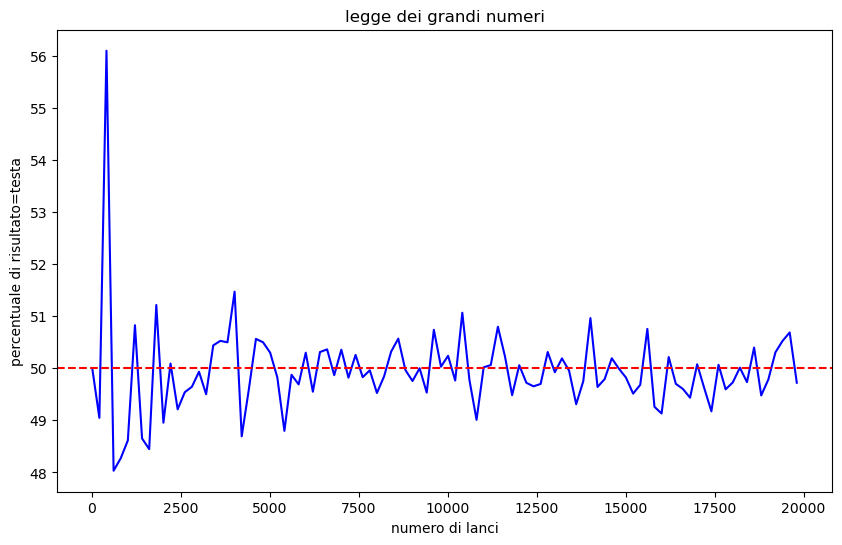

In [ ]:
#5

#1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

C:\Users\medic\AppData\Local\Temp\ipykernel_25384\222424052.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')


Text(0.5, 1.0, 'Distribuzione Età per Classe e Sesso')

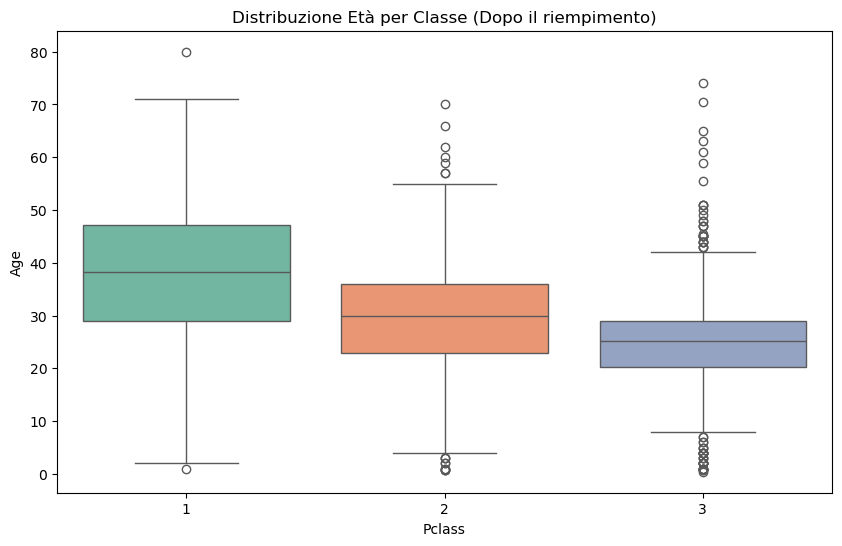

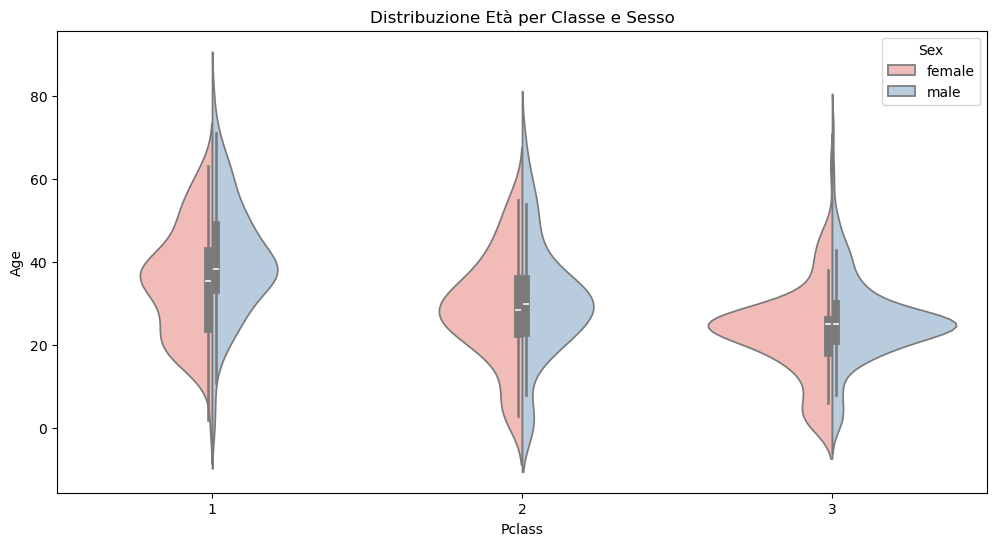

In [7]:
#2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

#Quante righe e colonne ha il dataset?
df.shape
#Controlla quanti valori mancanti ci sono per colonna
valori_mancanti = df.isnull().sum()
#Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
piu_freq_emarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(piu_freq_emarked)
#Controlla se ci sono righe duplicate
duplicati = df.duplicated().sum()
#Calcola l'età media dei passeggeri per ogni classe (Pclass), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))
#Visualizza la distribuzione dell'età per classe
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Distribuzione Età per Classe (Dopo il riempimento)')
#Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
plt.figure(figsize=(12, 6))
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=df, split=True, palette='Pastel1')
plt.title('Distribuzione Età per Classe e Sesso')

C:\Users\medic\AppData\Local\Temp\ipykernel_6372\2136477938.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_area', palette='Set2')


Text(0, 0.5, 'Area Petalo (L x P)')

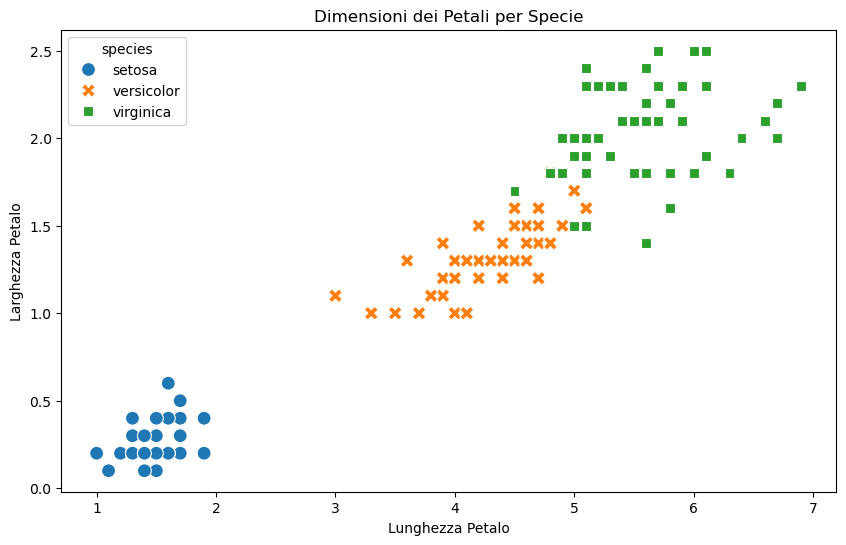

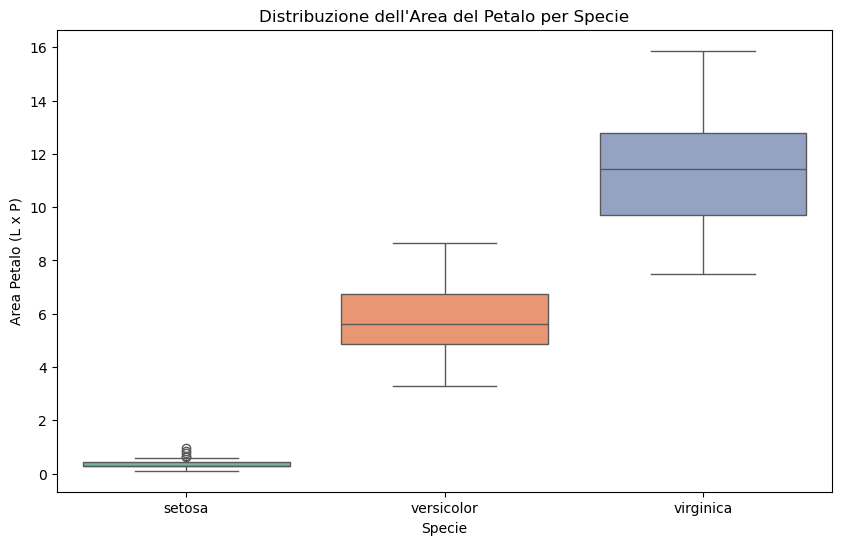

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

#3
#Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
conta_specie = df['species'].value_counts()
conta_specie
#Calcola la lunghezza e la larghezza media dei petali per specie
petali_media = df.groupby('species')[['petal_length', 'petal_width']].mean()
petali_media
#Visualizza le dimensioni dei petali per specie (scatterplot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', style='species', s=100)
plt.title('Dimensioni dei Petali per Specie')
plt.xlabel('Lunghezza Petalo')
plt.ylabel('Larghezza Petalo')
#Crea una nuova colonna per l'area del petalo e analizzala
df['petal_area'] = df['petal_length'] * df['petal_width']
area_stats = df.groupby('species')['petal_area'].describe()
#Grafico della distribuzione dell'area del petalo per specie (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='petal_area', palette='Set2')
plt.title('Distribuzione dell\'Area del Petalo per Specie')
plt.xlabel('Specie')
plt.ylabel('Area Petalo (L x P)')

